In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score

In [2]:
counts_log = pd.read_csv("../data/processed/log2_counts.csv", index_col=0)
metadata = pd.read_csv("../data/processed/metadata.csv")

metadata = metadata.set_index("sample_id")
metadata = metadata.loc[counts_log.index]

counts_log.shape, metadata.shape

((144, 39376), (144, 3))

In [3]:
X = counts_log
y = metadata["binary_class"]

y.value_counts()

binary_class
Epilepsy    121
Control      23
Name: count, dtype: int64

In [11]:
gene_variance = X.var(axis=0)

top_genes = gene_variance.sort_values(ascending=False).head(5000).index

X = X[top_genes]

X.shape

(144, 5000)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

y_train.value_counts(), y_test.value_counts()

(binary_class
 Epilepsy    91
 Control     17
 Name: count, dtype: int64,
 binary_class
 Epilepsy    30
 Control      6
 Name: count, dtype: int64)

**Logistic regression**

In [18]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

log_reg.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [19]:
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Control       0.83      0.83      0.83         6
    Epilepsy       0.97      0.97      0.97        30

    accuracy                           0.94        36
   macro avg       0.90      0.90      0.90        36
weighted avg       0.94      0.94      0.94        36



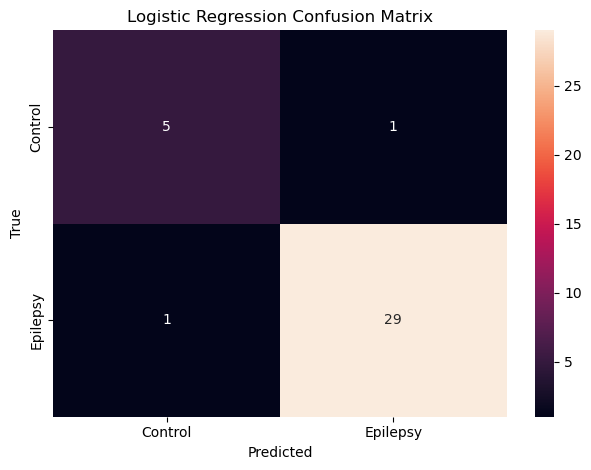

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=["Control", "Epilepsy"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Control", "Epilepsy"],
    yticklabels=["Control", "Epilepsy"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("../figures/logistic_regression_confusion_matrix.png", dpi=300)
plt.show()

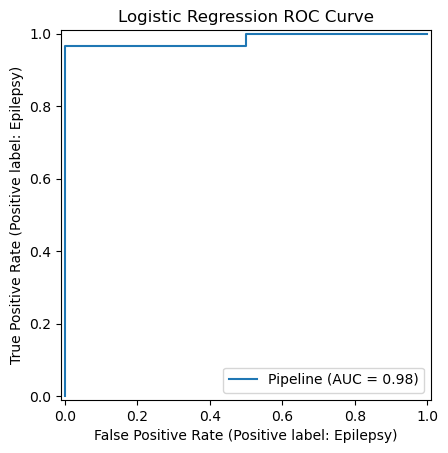

In [21]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_reg,
    X_test,
    y_test
)

plt.title("Logistic Regression ROC Curve")
plt.show()

The dataset is imbalanced with substantially fewer control samples than epilepsy samples. This means that model performance estimates should be interpreted with this in mind.

In [25]:
scores = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Mean AUC:", scores.mean())
print("SD:", scores.std())

Mean AUC: 0.9933333333333334
SD: 0.01333333333333333


In [26]:
cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "AUC": scores
})

cv_results

,Fold,AUC
0,1,1.000000
1,2,1.000000
2,3,0.966667
3,4,1.000000
4,5,1.000000


Logistic regression distinguished epilepsy from control samples with a mean 5-fold cross-validated ROC-AUC of 0.993 ± 0.013.

In [27]:
coef = pd.Series(
    log_reg.named_steps["model"].coef_[0],
    index=X.columns
)

top_positive = coef.sort_values(ascending=False).head(20)
top_negative = coef.sort_values().head(20)

**Random Forest**

In [29]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

     Control       0.80      0.67      0.73         6
    Epilepsy       0.94      0.97      0.95        30

    accuracy                           0.92        36
   macro avg       0.87      0.82      0.84        36
weighted avg       0.91      0.92      0.91        36



In [31]:
rf_probs = rf.predict_proba(X_test)[:, 1]

roc_auc_score(
    (y_test == "Epilepsy").astype(int),
    rf_probs
)

0.9888888888888889

In [32]:
rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(rf_scores)
print("Mean:", rf_scores.mean())
print("SD:", rf_scores.std())

[1.         0.99166667 0.96666667 1.         1.        ]
Mean: 0.9916666666666668
SD: 0.012909944487358053


Random forest distinguished epilepsy from control samples with a mean ROC-AUC of 0.992 ± 0.013.

In [35]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean_AUC": [scores.mean(), rf_scores.mean()],
    "SD": [scores.std(), rf_scores.std()]
})

model_comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)


model_comparison

,Model,Mean_AUC,SD
0,Logistic Regression,0.993333,0.013333
1,Random Forest,0.991667,0.012910


A simple linear model performs as well as a nonlinear ensemble model.

**Random Forest feature importance**

In [37]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top20 = importance.sort_values(
    ascending=False
).head(20)

top20

1524         0.019991
53829        0.018970
407975       0.016776
91703        0.015498
6404         0.015399
10170        0.014742
102724850    0.012643
3552         0.012080
100616259    0.011471
120939       0.011345
165904       0.011278
101929497    0.011079
107075116    0.010953
64805        0.010062
115650       0.009629
9023         0.009433
6348         0.009138
105373004    0.008814
102724104    0.008549
84002        0.007681
dtype: float64

In [41]:
annot = pd.read_csv(
    "../data/raw/Human.GRCh38.p13.annot.tsv.gz",
    sep="\t"
)

annot.head()

/var/folders/xh/6pcc89sj4fbd94qh_67hxjd80000gn/T/ipykernel_4999/3076191407.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  annot = pd.read_csv(


,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN


In [42]:
gene_map = dict(
    zip(
        annot["GeneID"].astype(str),
        annot["Symbol"]
    )
)

In [43]:
top20_named = top20.copy()

top20_named.index = [
    gene_map.get(str(gene), str(gene))
    for gene in top20_named.index
]

top20_named

CX3CR1          0.019991
P2RY13          0.018970
MIR17HG         0.016776
ACY3            0.015498
SELPLG          0.015399
DHRS9           0.014742
CCL3-AS1        0.012643
IL1A            0.012080
MIR378I         0.011471
TMEM52B         0.011345
XIRP1           0.011278
LINC02712       0.011079
MIR3142HG       0.010953
P2RY12          0.010062
TNFRSF13C       0.009629
CH25H           0.009433
CCL3            0.009138
SYN3-AS1        0.008814
LOC102724104    0.008549
B3GNT5          0.007681
dtype: float64

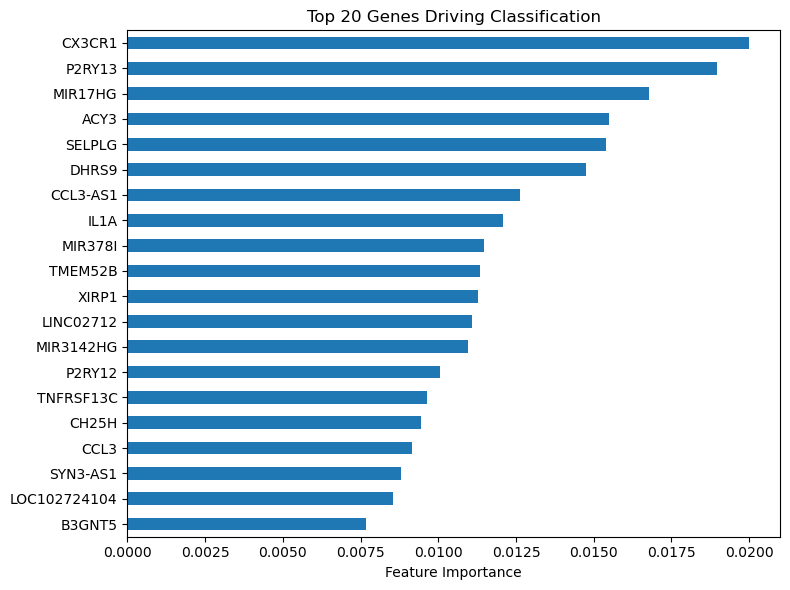

<Figure size 640x480 with 0 Axes>

In [53]:
plt.figure(figsize=(8,6))

top20_named.sort_values().plot.barh()

plt.xlabel("Feature Importance")
plt.title("Top 20 Genes Driving Classification")

plt.tight_layout()
plt.show()

plt.savefig("../figures/random_forest_top20_features.png", dpi=300, bbox_inches="tight")

The top genes involve include:

**CX3CR1** – microglial receptor, heavily studied in neuroinflammation.

**P2RY12** and **P2RY13** – classic microglial markers.

**IL1A** – inflammatory cytokine.

**CCL3** – chemokine involved in immune cell recruitment.

**CH25H** – immune/inflammatory responses.

This potentially suggests that immune-related transcriptional programs contribute substantially to the distinction between epilepsy and control samples.

In [51]:
importance_df = pd.DataFrame({
    "GeneID": importance.index,
    "Importance": importance.values
})

importance_df["Gene"] = importance_df["GeneID"].astype(str).map(gene_map)

importance_df = importance_df[
    ["GeneID", "Gene", "Importance"]
]

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.to_csv(
    "../results/random_forest_feature_importance.csv",
    index=False
)

In [52]:
importance_df.head()

,GeneID,Gene,Importance
743,1524,CX3CR1,0.019991
2520,53829,P2RY13,0.018970
2922,407975,MIR17HG,0.016776
383,91703,ACY3,0.015498
2549,6404,SELPLG,0.015399
